# ECサイトの売上分析
### TheLookecommerce
このノートブックでは、**TheLook_ecommerce**データセットを用いて、エンドツーエンドで分析したポートフォリオになっています。分析の目的は利益向上のために顧客の購買行動を分析し、改善施策を提案することである。RFM分析で顧客を分類し、コホート分析で継続率を検証することになっています。その結果をもとに施策提案し、利益向上への貢献可能性を評価します。

### 中核となる分析戦略
ECサイトの売上分析では、デモグラフィックを調べ上げ二つの分析方法をメインに進めていきます。
1. **RFM分析** 顧客をランクごとに分類し、デモグラフィックの情報と購入カテゴリ、時系列から判断し、顧客の購入傾向を判断します。
2. **カホート分析** リピーターの割合を示すものです。初回購入月ごとに顧客を分類し、継続率やリピート率を分析します。

### 分析内容
1. スキーマ構造とライブラリ・データの読み込み
2. デモグラフィック確認：ユーザー情報を正確に理解するため 
3. EDA分析：顧客属性を把握し、RFM分析やコホート分析の資料のため
4. RFM分析：顧客価値を把握するため
5. コホート分析：顧客の継続率を確認するため
6. 施策提案

## 1.スキーマ構造とライブラリ・データの読み込み
Bigqueryに保存されているTheLook_ecommerceのデータセットのusers・orders・order_items・productsテーブルを結合し、顧客行動と売上の関係を分析します。

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
sns.set()

df_profit = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\profit_data.csv")
df_user = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\user_data.csv")
df_monthly = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\monthly_data.csv")
df_rfm = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\RFM_data.csv")
df_rfm_category = pd.read_csv("RFM_age_category_customer_rank.csv")
df_cohort = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\cohort_data.csv")
df_cohort_age = pd.read_csv(r"C:\Users\gaku2\study\pandas\thelook_ecommerce\cohort_age_data.csv")

plt.rcParams["font.family"] = "Meiryo"
plt.rcParams["axes.unicode_minus"] = False

## 2.デモグラフィックの確認

この章では173,773行あるdf_profitデータを使用し、デモグラフィック(性別、年齢)を中心にその要素に付随する形でカテゴリ、利益、購入数、時系列の関係を調べます。今後、この章で分析した内容を踏まえてRFM分析やコホート分析を評価し検証、評価していきます。


In [27]:
df_profit

,user_id,age_group,gender,category,price_group,order_count,total_price,avg_sale_price,total_profit,avg_profit_rate
0,29134,50代,M,Outerwear & Coats,高価格,1,1242.00000,621.000000,699.713998,57.7
1,68352,60代以上,F,Outerwear & Coats,高価格,1,1220.98999,610.494995,659.091426,54.3
2,7636,60代以上,M,Outerwear & Coats,高価格,1,999.00000,999.000000,594.404999,59.5
3,49070,60代以上,M,Outerwear & Coats,高価格,1,999.00000,999.000000,594.404999,59.5
4,40059,40代,M,Outerwear & Coats,高価格,1,999.00000,999.000000,594.404999,59.5
...,...,...,...,...,...,...,...,...,...,...
173768,85601,20代,F,Accessories,低価格,1,0.49000,0.490000,0.312620,63.8
173769,93447,10代,F,Accessories,低価格,1,0.02000,0.020000,0.011700,58.5
173770,34271,40代,F,Accessories,低価格,1,0.02000,0.020000,0.011700,58.5
173771,6916,10代,F,Accessories,低価格,1,0.02000,0.020000,0.011700,58.5


In [28]:
agg_cols = {
    "user_id": "nunique",
    "order_count": "sum",
    "total_price": "sum",
    "total_profit": "sum",
    "avg_sale_price": "mean"
}

print("性別ごと")
display(df_profit.groupby("gender").agg(agg_cols))

print("年齢グループごと")
display(df_profit.groupby("age_group").agg(agg_cols))

性別ごと


,user_id,order_count,total_price,total_profit,avg_sale_price
gender,,,,,
F,39881,88956,5.030663e+06,2.617730e+06,56.528239
M,40207,89510,5.794672e+06,3.003115e+06,64.643940


年齢グループごと


,user_id,order_count,total_price,total_profit,avg_sale_price
age_group,,,,,
10代,10752,24111,1.473298e+06,7.647235e+05,61.060955
20代,13599,30417,1.838149e+06,9.535391e+05,60.397516
30代,13593,30175,1.820174e+06,9.438442e+05,60.173874
40代,13670,30582,1.838378e+06,9.560725e+05,60.097253
50代,13573,30053,1.828310e+06,9.485543e+05,60.698039
60代以上,14901,33128,2.027025e+06,1.054111e+06,61.175269


### デモグラフィックと購入数・利益の考察
**性別による情報** 男性の方が売上や購入回数が多いが女性との差は少ないことが分かります。このような差が生じたのも、平均購入金額(avg_sale_price)に8$の差があることに加えて、購入数に400程差があることからこのような変化が生まれたことが考えられます。

**年齢別による情報** 平均購入金額にあまり差はありませんでしたが、60代以上の顧客数が多いことが分かります。平均購入額に差がないので購入数がカギになってくると考えられます。

## 3.EDA分析
この章では、カテゴリと時系列を軸としてデータの把握をするためにEDA分析を行います。顧客情報、利益を踏まえて分析をします。

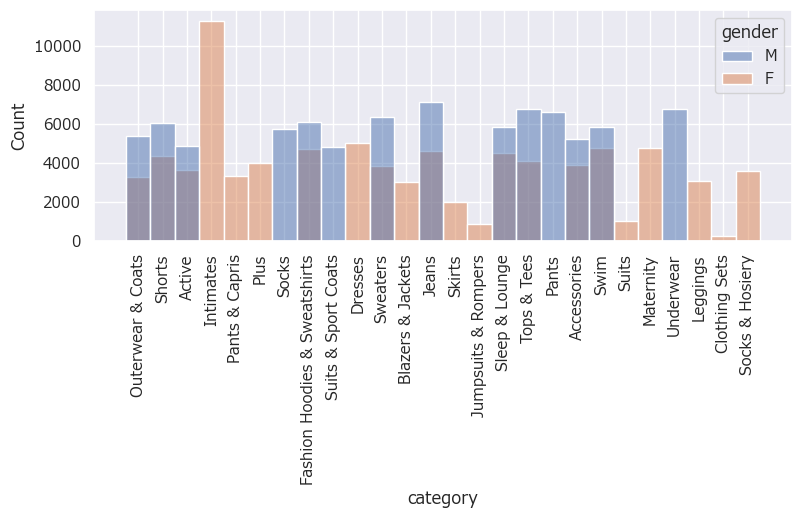

In [29]:
plt.figure(figsize = (9,3))

sns.histplot(
    data =  df_user,
    x = "category",
    hue = "gender"
)

plt.xticks(rotation=90)
plt.savefig("category_count.png",
            bbox_inches="tight")
plt.show()


女性の購入している商品が26種類中22種類と多いことが分かります。また、男性のみの商品が4種類、女性のみの商品が12種類、共通の種類は10種類であることが分かります。女性は男性に比べてカテゴリごとの購入数に大きく差があることも分かります。このことから、女性に対して、カテゴリにおいて幅広い施策を打つことができると考えます。また、男性は、購入数がどのカテゴリも近いので利益の大きい商品を中心に施策を打ちたいと考えます。

### カテゴリごとの価格帯分類と利益分析
ここでは、商品の価格を5つのグループに分けてどの価格帯が最も売れているのかを可視化します。

In [30]:
df_profit.groupby("price_group").agg({
    "order_count":"sum",
    "total_price":"sum",
    "total_profit":"sum"
})

,order_count,total_price,total_profit
price_group,,,
中低価格,44827,3.192991e+06,1.634465e+06
中価格,19843,2.846585e+06,1.487686e+06
中高価格,3594,8.803570e+05,4.833890e+05
低価格,108352,3.042615e+06,1.538797e+06
高価格,1850,8.627866e+05,4.765081e+05


In [31]:
df_profit.groupby("category")["avg_sale_price"].mean().sort_values(ascending=False)

category
Outerwear & Coats                146.859835
Suits & Sport Coats              126.047245
Suits                            115.466929
Jeans                             97.985396
Blazers & Jackets                 93.982311
Dresses                           84.097365
Clothing Sets                     81.387851
Sweaters                          75.229069
Pants                             60.875048
Swim                              57.256780
Skirts                            55.368139
Fashion Hoodies & Sweatshirts     54.005139
Pants & Capris                    53.732566
Active                            51.866218
Maternity                         51.562815
Sleep & Lounge                    49.765973
Shorts                            47.096836
Jumpsuits & Rompers               45.832877
Accessories                       43.389456
Tops & Tees                       41.832284
Plus                              40.226110
Intimates                         34.409068
Underwear              

価格帯が低ければ低いほど購入数が多いことが分かります。ただ、価格が低いため、購入数が多くても総売上や総利益が他の価格帯よりも高くなるとは言えません。カテゴリごとの利益を見ると、幅広く分布されているため、購入数を増やすことも必要であるが、いかに高額商品を目的に買い物をしてもらいそこに付随する形で価格の低い商品を購入してもらうかということが大切だと考えます。

### 年齢グループ×カテゴリの購入数・総売上の関係分析
10代、20代、30代、40代、50代、60代以上に分類し、どの年代の顧客がどの商品をよく購入しているかの傾向を可視化します。また、年代別による購入数と総売上の結果を比較し、年代別で施策を考えるための情報をまとめます。

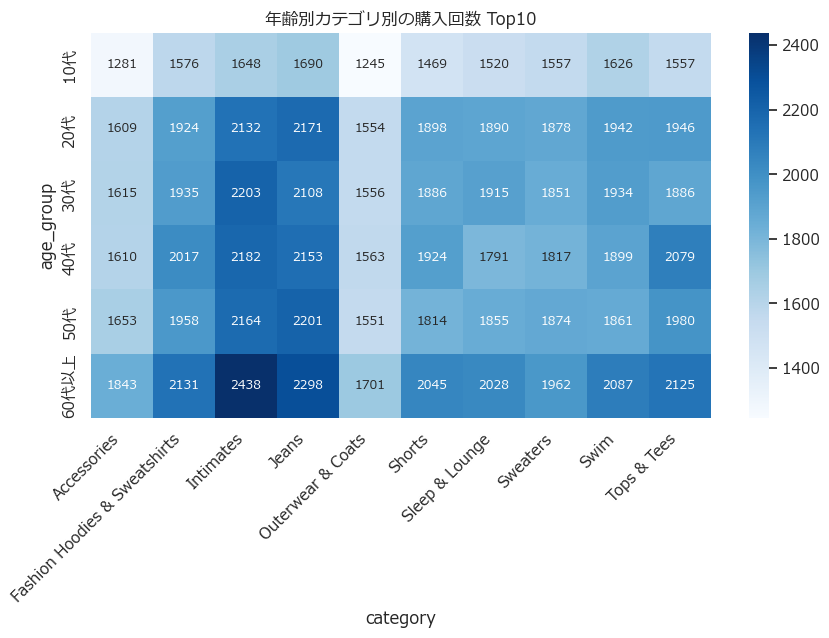

In [32]:
top_categories = (
    df_profit.groupby("category")["order_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = df_profit[df_profit["category"].isin(top_categories)]

age_category_sales_count_top = df_top.pivot_table(
    index="age_group",
    columns="category",
    values="order_count",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    age_category_sales_count_top,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 9}
)

plt.xlabel("category")
plt.ylabel("age_group")
plt.title("年齢別カテゴリ別の購入回数 Top10")
plt.xticks(rotation=45, ha="right")
plt.show()

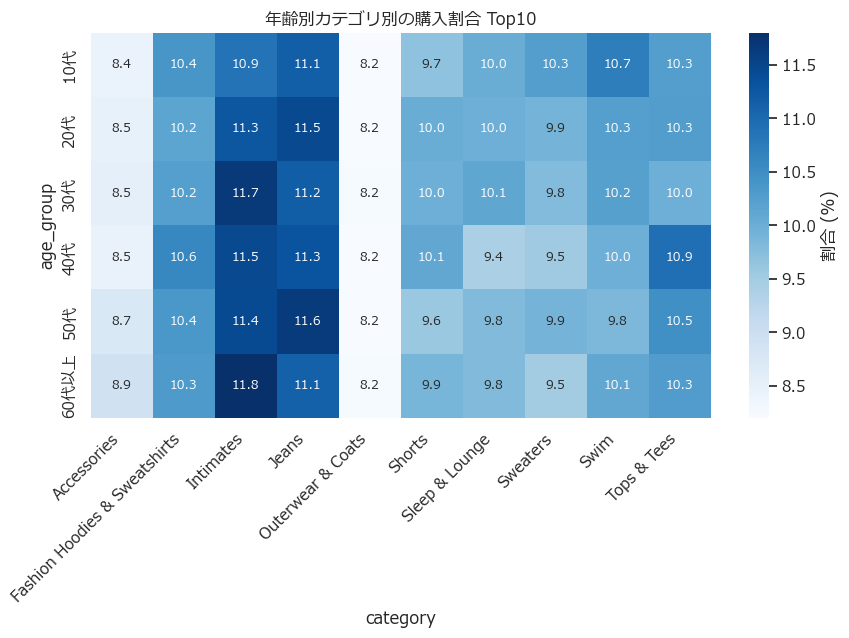

In [33]:
top_categories = (
    df_profit.groupby("category")["order_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = df_profit[df_profit["category"].isin(top_categories)]

age_category_sales_count_top = df_top.pivot_table(
    index="age_group",
    columns="category",
    values="order_count",
    aggfunc="sum",
    fill_value=0
)


age_category_sales_ratio_top = (
    age_category_sales_count_top
    .div(age_category_sales_count_top.sum(axis=1), axis=0)
    * 100
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    age_category_sales_ratio_top,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 9},
    cbar_kws={"label": "割合 (%)"}
)

plt.xlabel("category")
plt.ylabel("age_group")
plt.title("年齢別カテゴリ別の購入割合 Top10")
plt.xticks(rotation=45, ha="right")
plt.show()

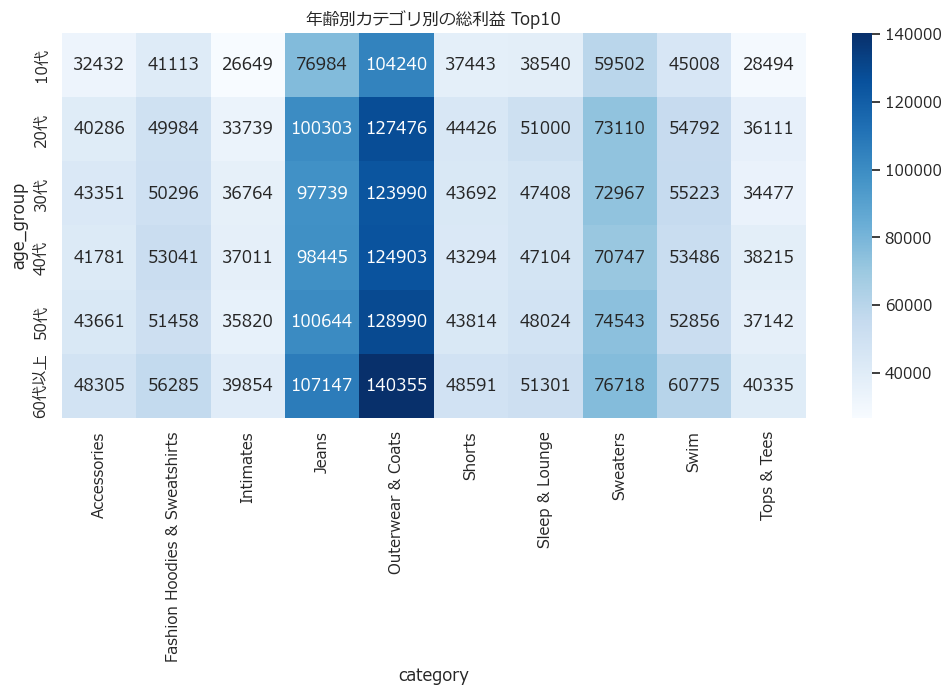

In [34]:
df_top = df_profit[df_profit["category"].isin(top_categories)]

age_category_sales_price_top = df_top.pivot_table(
    index="age_group",
    columns="category",
    values="total_profit",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12, 5))

sns.heatmap(
    age_category_sales_price_top,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

plt.xlabel("category")
plt.ylabel("age_group")
plt.title("年齢別カテゴリ別の総利益 Top10")
plt.show()

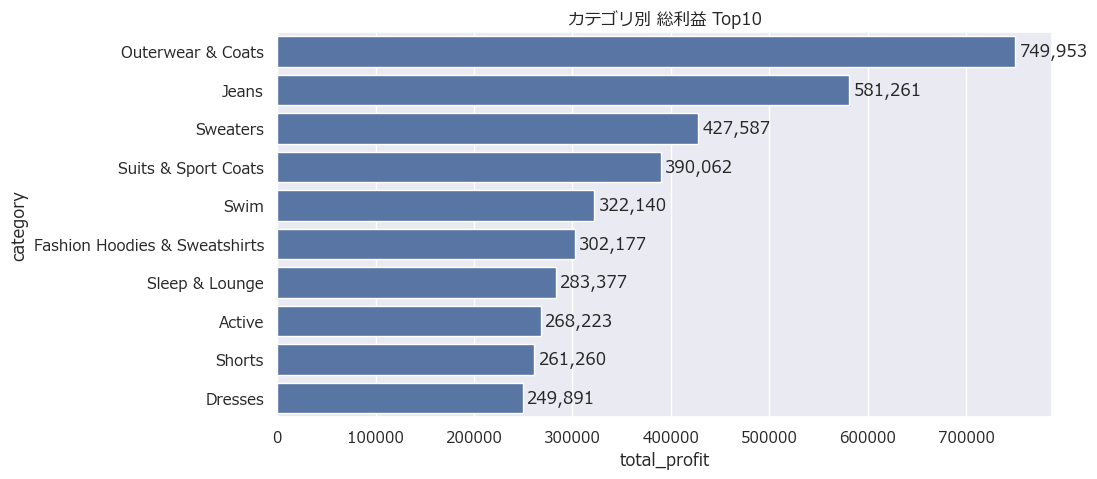

In [35]:
category_profit_top10 = (
    df_profit.groupby("category")["total_profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=category_profit_top10.values,
    y=category_profit_top10.index
)

ax.bar_label(
    ax.containers[0],
    labels=[f"{v:,.0f}" for v in category_profit_top10.values],
    padding=3
)

plt.xlabel("total_profit")
plt.ylabel("category")
plt.title("カテゴリ別 総利益 Top10")
plt.show()

60代の購入数はどのカテゴリもほかの年代に比べて多いことが分かります。その中でもOUterwearやAccessoriesの購入数が他の年代と比べて多いことが分かります。割合で見ると10代はSwim、40代はTops & Teesの購入割合が高いことが分かります。以上のことから各年代においてJeaans,Intimates以外に購入数の多いカテゴリが存在するのでターゲットを絞った施策を打つことができると考えます。また、利益で見るとOuterwearやJeansが大きいことが分かります。また、Dressesは女性のみの購入にも関わらず、10位の利益を出しているので、女性に向けたDressesを販売するのも一つの手であると考えます。

### 時系列とカテゴリの関係
カテゴリにもSwimなどの季節によって使用の有無が変わる商品などが存在するのかの確認をします。どの月にどれほど売れているのかを確認することで、今後のカテゴリに関連する施策の手助けになる情報を探していきます。

In [36]:
df_monthly

,category,order_month,order_count,monthly_sales,avg_price
0,Jeans,2026-05-01,976,96211.870092,98.577736
1,Outerwear & Coats,2026-05-01,653,91263.669930,139.760597
2,Sweaters,2026-05-01,860,62907.740002,73.148535
3,Outerwear & Coats,2026-04-01,396,59021.809980,149.044975
4,Outerwear & Coats,2026-03-01,377,58218.869896,154.426711
...,...,...,...,...,...
2239,Socks & Hosiery,2019-04-01,1,11.340000,11.340000
2240,Jumpsuits & Rompers,2019-12-01,1,10.890000,10.890000
2241,Jumpsuits & Rompers,2019-11-01,1,9.990000,9.990000
2242,Socks & Hosiery,2019-05-01,1,8.490000,8.490000


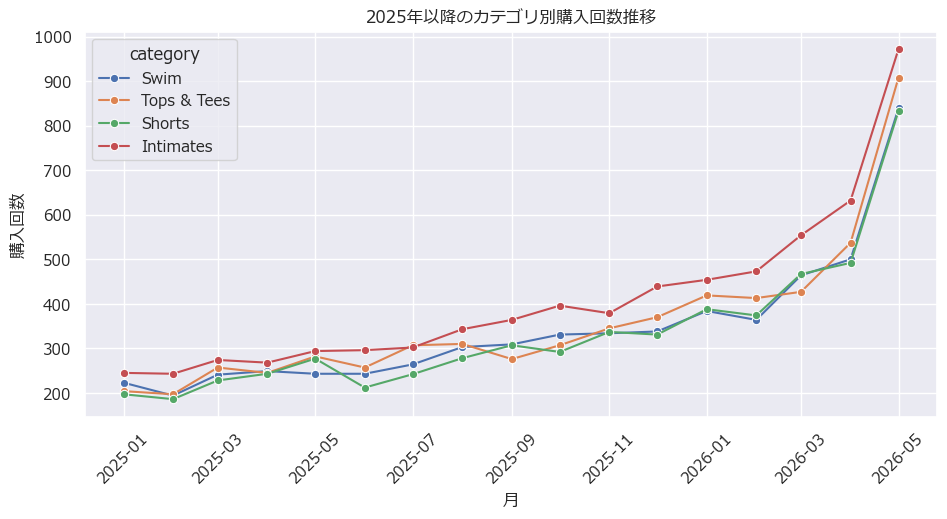

In [37]:
df_monthly["order_month"] = pd.to_datetime(df_monthly["order_month"])

target_summer_categories = ["Swim","Intimates","Shorts","Swim","Tops & Tees"]

df_category_2025 = df_monthly[
    (df_monthly["category"].isin(target_summer_categories)) &
    (df_monthly["order_month"] >= "2025-01-01")
].copy()

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=df_category_2025,
    x="order_month",
    y="order_count",
    hue="category",
    marker="o"
)

plt.title("2025年以降のカテゴリ別購入回数推移")
plt.xlabel("月")
plt.ylabel("購入回数")
plt.xticks(rotation=45)
plt.legend(title="category")
plt.show()

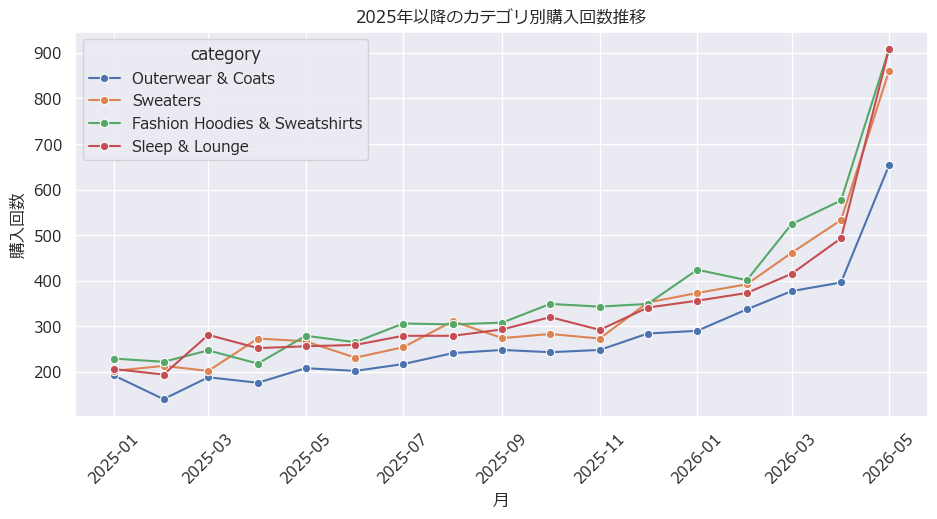

In [38]:
df_monthly["order_month"] = pd.to_datetime(df_monthly["order_month"])

target_winter_categories = ["Fashion Hoodies & Sweatshirts","Outerwear & Coats","Sweaters","Sleep & Lounge"]

df_category_2025 = df_monthly[
    (df_monthly["category"].isin(target_winter_categories)) &
    (df_monthly["order_month"] >= "2025-01-01")
].copy()

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=df_category_2025,
    x="order_month",
    y="order_count",
    hue="category",
    marker="o"
)

plt.title("2025年以降のカテゴリ別購入回数推移")
plt.xlabel("月")
plt.ylabel("購入回数")
plt.xticks(rotation=45)
plt.legend(title="category")
plt.show()

時期によって購入数の違いはあまり見られなかったが、その中でも、Shortsは6月の夏の時期に購入数が100個程変動し、Sleep & Loungeは2~3月の冬の時期に購入数が100個程変動していることが分かる。また、2026年に入ってから購入数が大幅に伸びていることも確認できる。このことから、ここ最近の購入傾向を分析することで利益向上の課題を見つけることができる可能性があると考えます。

## 4. RFM分析
この章では顧客をrecency,frequency,monetalyの三つの観点から4つのランクに分け、顧客ランクごとの購入傾向を確認します。また、顧客ランクが変更になった場合の利益の増加も確認し、効率よく利益を上げるために最適なターゲットを絞るためにここでは顧客ランクの分析を行います。

In [39]:
df_rfm

,user_id,gender,age,first_purchase_date,last_purchase_date,recency,frequency,monetary,total_profit,avg_profit,avg_price
0,58307,M,30,2023-08-16,2024-04-29,769,2,1527.480003,887.365212,177.473042,305.496001
1,44879,F,33,2025-05-22,2025-11-29,190,2,1483.940001,761.814471,95.226809,185.492500
2,79661,M,38,2021-11-13,2025-03-22,442,2,1449.979998,795.677587,132.612931,241.663333
3,44644,F,56,2026-04-24,2026-06-01,6,4,1440.090012,753.231004,75.323100,144.009001
4,82375,M,68,2024-02-08,2026-01-17,141,3,1358.509996,741.256246,123.542708,226.418333
...,...,...,...,...,...,...,...,...,...,...,...
53108,40351,F,57,2020-09-18,2020-09-18,2088,1,1.510000,0.865230,0.865230,1.510000
53109,41018,F,45,2023-06-28,2023-06-28,1075,1,1.510000,0.865230,0.865230,1.510000
53110,13451,F,46,2022-11-23,2022-11-23,1292,1,1.500000,0.882000,0.882000,1.500000
53111,79882,F,46,2026-04-14,2026-04-14,54,1,1.500000,0.882000,0.882000,1.500000


In [40]:
df_rfm[["recency", "frequency", "monetary"]].describe()

,recency,frequency,monetary
count,53113.000000,53113.000000,53113.000000
mean,603.659048,1.301263,113.322808
std,570.328395,0.592106,120.306645
min,0.000000,1.000000,1.500000
25%,142.000000,1.000000,36.000000
50%,422.000000,1.000000,73.070002
75%,921.000000,1.000000,149.500000
max,2692.000000,4.000000,1527.480003


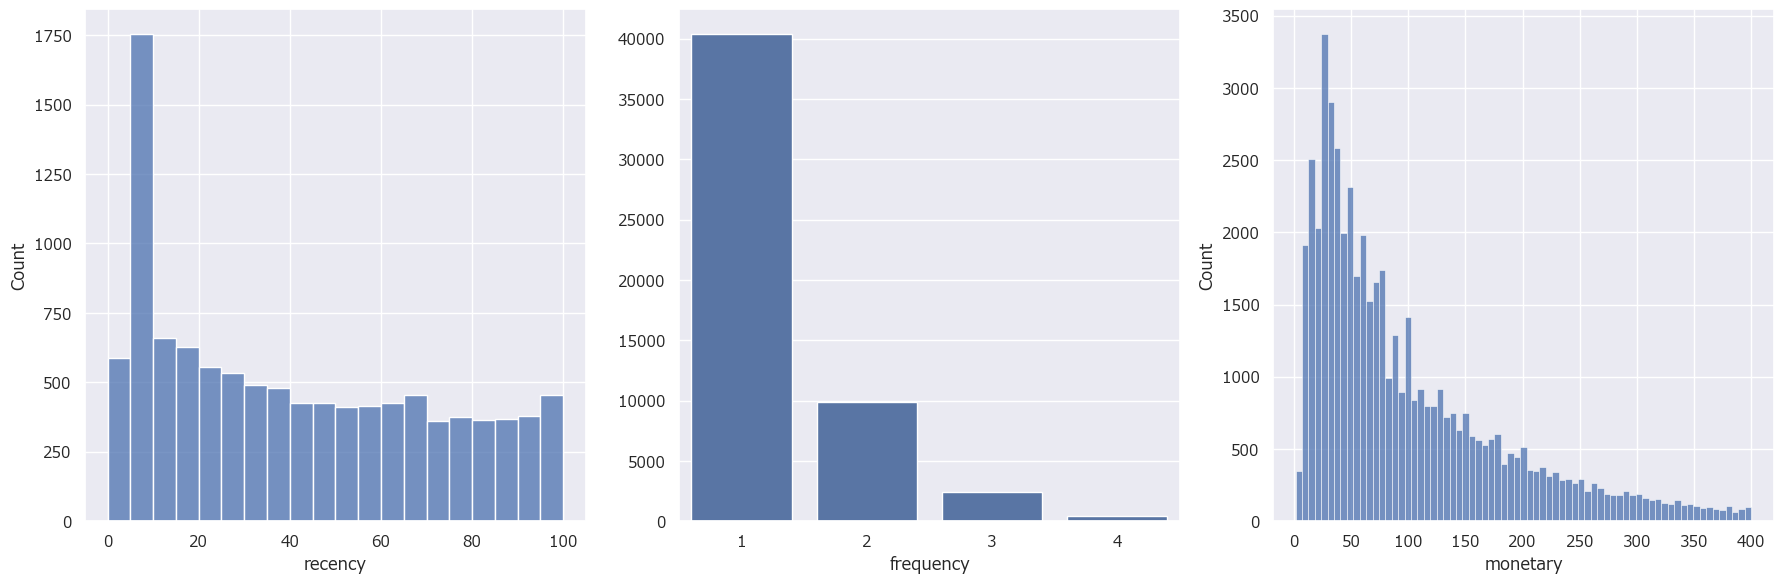

frequency
1    40400
2     9857
3     2424
4      432
Name: count, dtype: int64
一回購入者の割合：76.1%


In [53]:
freq_count = (
    df_rfm["frequency"]
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(
    data = df_rfm[df_rfm["recency"] <= 100],
    x = "recency",
    ax=axes[0]
)
sns.barplot(
    x=freq_count.index,
    y=freq_count.values,
    ax=axes[1]
)
sns.histplot(
    data = df_rfm[df_rfm["monetary"] <= 400],
    x = "monetary",
    ax=axes[2]
)
plt.tight_layout()
plt.savefig("rfm_data.png",
            dpi=500,
            bbox_inches="tight")
plt.show()

df_rfm["frequency"].value_counts()
print(df_rfm["frequency"].value_counts())

one_time_rate = (40400 / 53113) * 100
print("一回購入者の割合：" + str(round(one_time_rate, 1)) + "%")

In [42]:
df_rfm["R_score"] = pd.qcut(
    df_rfm["recency"],
    4,
    labels=[4, 3, 2, 1]
)

df_rfm["F_score"] = pd.qcut(
    df_rfm["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
)

df_rfm["M_score"] = pd.qcut(
    df_rfm["monetary"],
    4,
    labels=[1, 2, 3, 4]
)

df_rfm["RFM_score"] = (
    df_rfm["R_score"].astype(int)
    + df_rfm["F_score"].astype(int)
    + df_rfm["M_score"].astype(int)
)

def customer_rank(score):
    if score >= 10:
        return "VIP顧客"
    elif score >= 8:
        return "優良顧客"
    elif score >= 6:
        return "一般顧客"
    else:
        return "離脱危険顧客"

df_rfm["customer_rank"] = df_rfm["RFM_score"].apply(customer_rank)

df_rfm["age_group"] = pd.cut(
    df_rfm["age"],
    bins=[0,20,30,40,50,60,100],
    labels=["10代","20代","30代","40代","50代","60代以上"],
    right=False
)

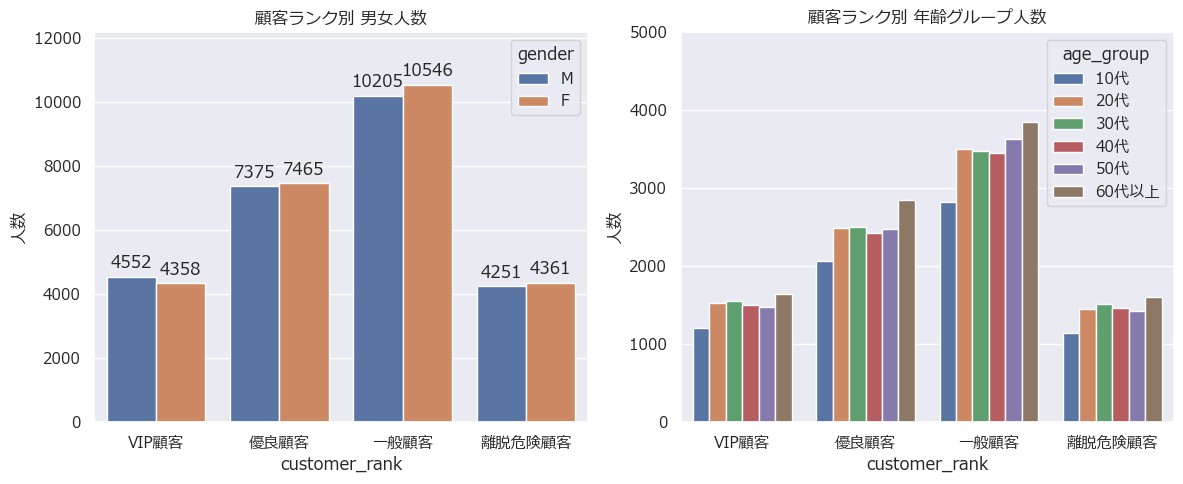

In [43]:
rank_order = [
    "VIP顧客",
    "優良顧客",
    "一般顧客",
    "離脱危険顧客"
]

gender_count = pd.crosstab(
    df_rfm["customer_rank"],
    df_rfm["gender"]
).reindex(rank_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax_gender = sns.countplot(
    data=df_rfm,
    x="customer_rank",
    hue="gender",
    order=rank_order,
    ax=axes[0]
)

ax_age = sns.countplot(
    data=df_rfm,
    x="customer_rank",
    hue="age_group",
    order=rank_order,
    ax=axes[1]
)

for container in ax_gender.containers:
    ax_gender.bar_label(container, fmt="%.0f", padding=3)

axes[0].set_xlabel("customer_rank")
axes[0].set_ylabel("人数")
axes[0].set_title("顧客ランク別 男女人数")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_ylim(0, ax_gender.get_ylim()[1] * 1.1)

axes[1].set_xlabel("customer_rank")
axes[1].set_ylabel("人数")
axes[1].set_title("顧客ランク別 年齢グループ人数")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, 5000)

plt.tight_layout()
plt.show()

In [44]:
print("顧客ランク別 平均購入金額")
print(df_rfm.groupby("customer_rank")["monetary"].mean().sort_values(ascending=False))

print()

print("顧客ランク別 平均購入回数")
print(df_rfm.groupby("customer_rank")["frequency"].mean().sort_values(ascending=False))
print()

print("顧客ランク別 総利益")
print(df_rfm.groupby("customer_rank")["total_profit"].sum().apply(lambda x: f"{x:,.0f}"))

顧客ランク別 平均購入金額
customer_rank
VIP顧客     226.068888
優良顧客      113.947441
一般顧客       89.043021
離脱危険顧客     54.102271
Name: monetary, dtype: float64

顧客ランク別 平均購入回数
customer_rank
VIP顧客     2.321886
優良顧客      1.258019
一般顧客      1.018987
離脱危険顧客    1.000000
Name: frequency, dtype: float64

顧客ランク別 総利益
customer_rank
VIP顧客     1,047,802
一般顧客        960,834
優良顧客        878,927
離脱危険顧客      237,723
Name: total_profit, dtype: object


初回購入のみの顧客がほとんどであるため、今後はリピーターを増やすことが課題として挙げられます。また、顧客ランクの中で、男女の人数差は見受けられませんでした。そこで、VIP顧客は一般顧客と比べて購入金額が**2.62倍**、購入回数は**2.3倍**と大きな差があるにも関わらず、総利益に差が小さいことが分かります。これは、顧客の人数が大きく関係していると考えられます。なので、VIP顧客1人当たりの利益は高いため、優良顧客からVIP顧客への育成は利益向上に有効である可能性が高いと考えます。

### 顧客ランクごとの利益増加
顧客ランクが一つ上がることで、一人当たりどれほどの利益が生まれるのかを確認することで、施策をあてるターゲットを限定しやすくします。

In [54]:
rank_profit = df_rfm.groupby("customer_rank").agg(
    user_count=("user_id", "nunique"),
    total_profit=("total_profit", "sum"),
    avg_profit_per_user=("total_profit", "mean")
).reset_index()

print(rank_profit)

# ランクアップした場合の利益の理論値
avg_general = rank_profit.loc[
    rank_profit["customer_rank"] == "一般顧客",
    "avg_profit_per_user"
].iloc[0]

avg_good = rank_profit.loc[
    rank_profit["customer_rank"] == "優良顧客",
    "avg_profit_per_user"
].iloc[0]

avg_vip = rank_profit.loc[
    rank_profit["customer_rank"] == "VIP顧客",
    "avg_profit_per_user"
].iloc[0]

general_to_good_profit = avg_good - avg_general
good_to_vip_profit = avg_vip - avg_good
print()
print("一般顧客 → 優良顧客 の1人あたり利益増加:", general_to_good_profit)
print("優良顧客 → VIP顧客 の1人あたり利益増加:", good_to_vip_profit)
df_rfm.to_csv("rfm_analysis.csv", index=False)

  customer_rank  user_count  total_profit  avg_profit_per_user
0         VIP顧客        8910  1.047802e+06           117.598460
1          一般顧客       20751  9.608343e+05            46.303038
2          優良顧客       14840  8.789269e+05            59.226878
3        離脱危険顧客        8612  2.377230e+05            27.603688

一般顧客 → 優良顧客 の1人あたり利益増加: 12.923840254647217
優良顧客 → VIP顧客 の1人あたり利益増加: 58.37158118164843


一般顧客を優良顧客にランクアップすることで**一人当たりの利益が12.9$、優良顧客をVIP顧客にランクアップすると一人当たりの利益が58.3$**と、二つを比較すると**4.5倍**の利益の大きさの違いがあることが分かります。ターゲットを優良顧客に絞り、年代別に施策を充て、VIP顧客へのランクアップを狙うべきだと考えます。

### 顧客ランク×カテゴリ×購入回数分析
この章ではその顧客ランクごとに、どのカテゴリがよく購入されているのか、売上に貢献しているカテゴリは何かを確認します。母数が異なるので割合で表すことにより相対的に判断することにします。

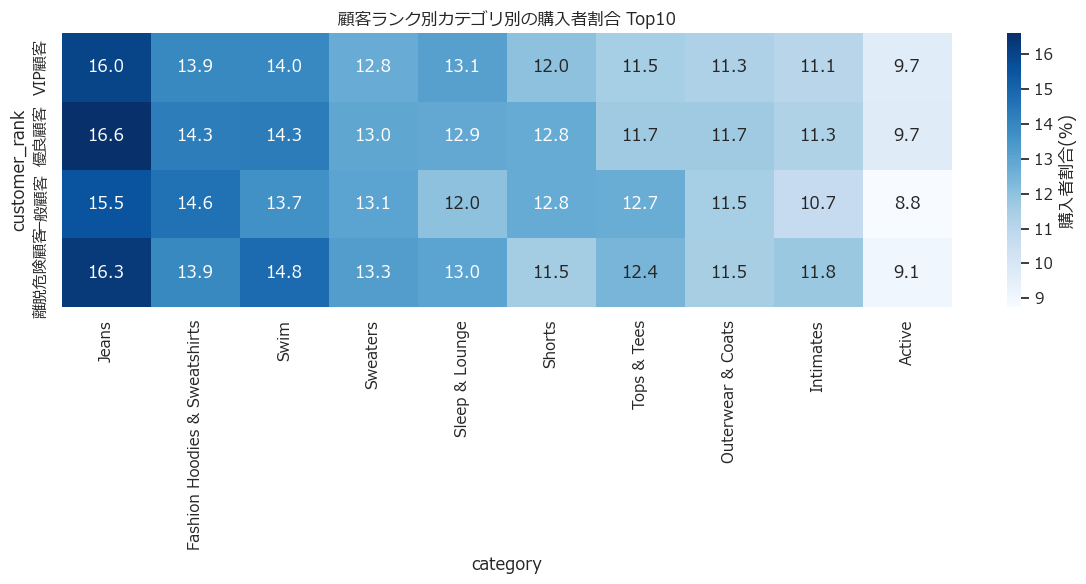

In [52]:
rank_order = ["VIP顧客", "優良顧客", "一般顧客", "離脱危険顧客"]

top_categories = (
    df_rfm_category
    .drop_duplicates(["user_id", "category"])
    .groupby("category")["user_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

rank_user_count = (
    df_rfm_category[["user_id", "customer_rank"]]
    .drop_duplicates()
    .groupby("customer_rank")["user_id"]
    .nunique()
)

rank_category_users = (
    df_rfm_category[df_rfm_category["category"].isin(top_categories)]
    .drop_duplicates(["user_id", "customer_rank", "category"])
    .groupby(["customer_rank", "category"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

rank_category_rate = (
    rank_category_users
    .div(rank_user_count, axis=0)
    * 100
)

rank_category_rate = rank_category_rate.reindex(
    index=rank_order,
    columns=top_categories
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    rank_category_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "購入者割合(%)"}
)

plt.title("顧客ランク別カテゴリ別の購入者割合 Top10")
plt.xlabel("category")
plt.ylabel("customer_rank")
plt.tight_layout()
plt.savefig("rfm_category.png",
            dpi=500,
            bbox_inches="tight")
plt.show()

VIP顧客と優良顧客の合計割合が**126%程度**であり、購入しているカテゴリ傾向は似ている部分が多いことが分かります。また左5列の購入割合が高いことも分かります。優良顧客をVIP顧客に育成するためには、リピート率の増加、単価の高い商品の購入などがあげられます。実際にEDA分析で購入している価格帯は**50$前後**の商品が多いことが分かっているので、高価格帯商品の購入促進施策を考え、そこからリピーターやクロスセルでほかの安めの商品を購入してもらうという流れを作るべきかと考えます。

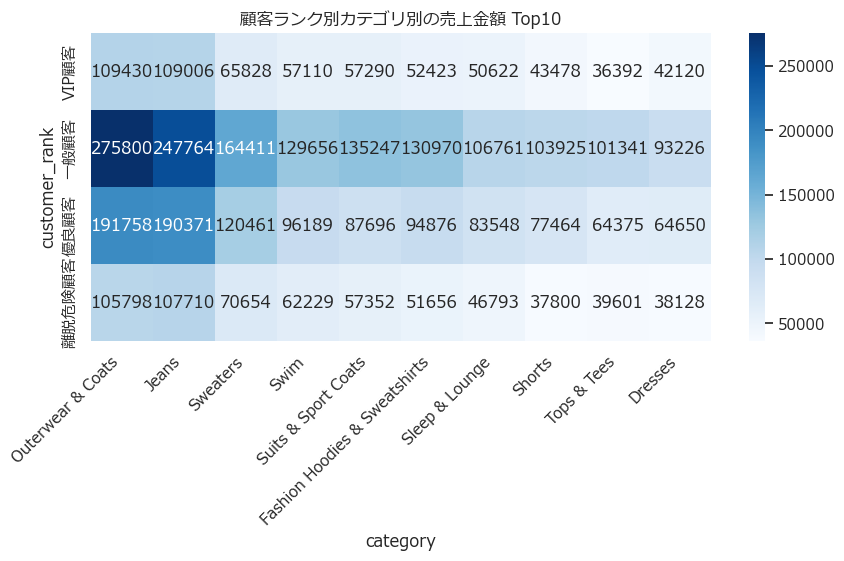

In [47]:
rfm_category_profit_table = df_rfm_category.pivot_table(
    index="customer_rank",
    columns="category",
    values="total_price",
    aggfunc="sum",
    fill_value=0
)

top_profit_categories = (
    rfm_category_profit_table
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

rfm_category_profit_top = rfm_category_profit_table[top_profit_categories]

plt.figure(figsize=(10, 4))

sns.heatmap(
    rfm_category_profit_top,
    cmap="Blues",
    annot=True,
    fmt=".0f"
)

plt.xlabel("category")
plt.ylabel("customer_rank")
plt.title("顧客ランク別カテゴリ別の売上金額 Top10")
plt.xticks(rotation=45, ha="right")
plt.show()

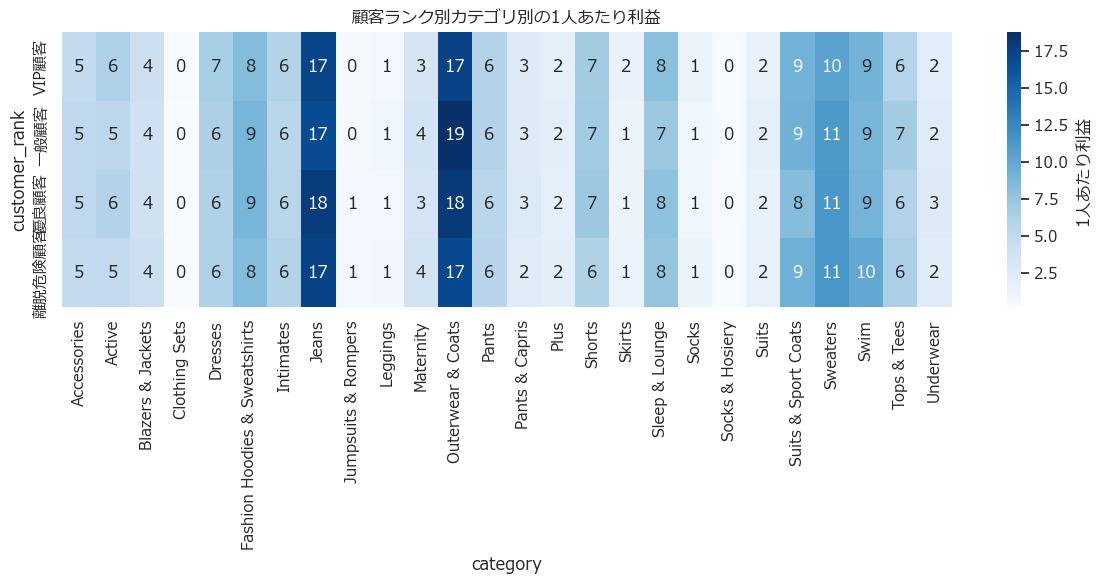

In [48]:
rank_user_count = (
    df_rfm_category[["user_id", "customer_rank"]]
    .drop_duplicates()
    .groupby("customer_rank")["user_id"]
    .nunique()
)

# 顧客ランク×カテゴリ別の利益合計
rank_category_profit = (
    df_rfm_category
    .groupby(["customer_rank", "category"])["total_price"]
    .sum()
    .unstack(fill_value=0)
)

# 1人あたり利益
rank_category_profit_per_user = (
    rank_category_profit
    .div(rank_user_count, axis=0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    rank_category_profit_per_user,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar_kws={"label": "1人あたり利益"}
)

plt.title("顧客ランク別カテゴリ別の1人あたり利益")
plt.xlabel("category")
plt.ylabel("customer_rank")
plt.tight_layout()
plt.show()

売上金額の合計だと一般顧客が母数が多いためとても多く見えるので、こちらも割合で表すことにします。基本的にどの顧客ランクも一人当たり近しい金額を払っていることが分かります。また、金額が0のカテゴリが存在することもわかります。このことから、0のカテゴリを売りに出すよりも、一人当たりの金額が高いカテゴリの商品のバリエーションを増やすことが有効である可能性があります。

## 5.コホート分析
この章では、顧客がいつ離脱しているのか。年代ごとに分け検証します。また、この分析を経て最終的な施策に落とし込んでいきます。

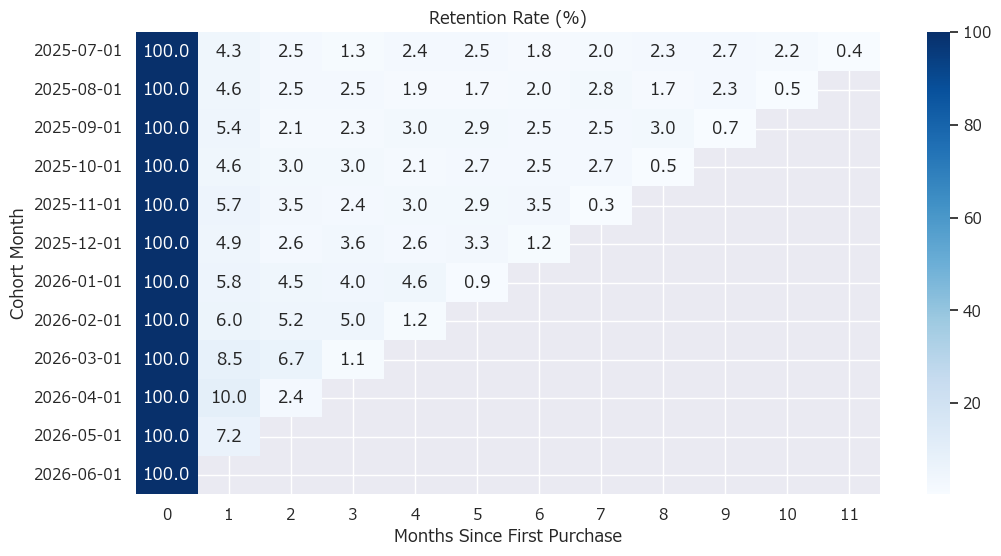

In [49]:
cohort_pivot = df_cohort.pivot(
    index="cohort_month",
    columns="month_number",
    values="retention_rate"
)
cohort_pivot = cohort_pivot.iloc[-12:, :12]
plt.figure(figsize=(12,6))

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Retention Rate (%)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.savefig("Retention_Rate.png",
            bbox_inches="tight")

plt.show()

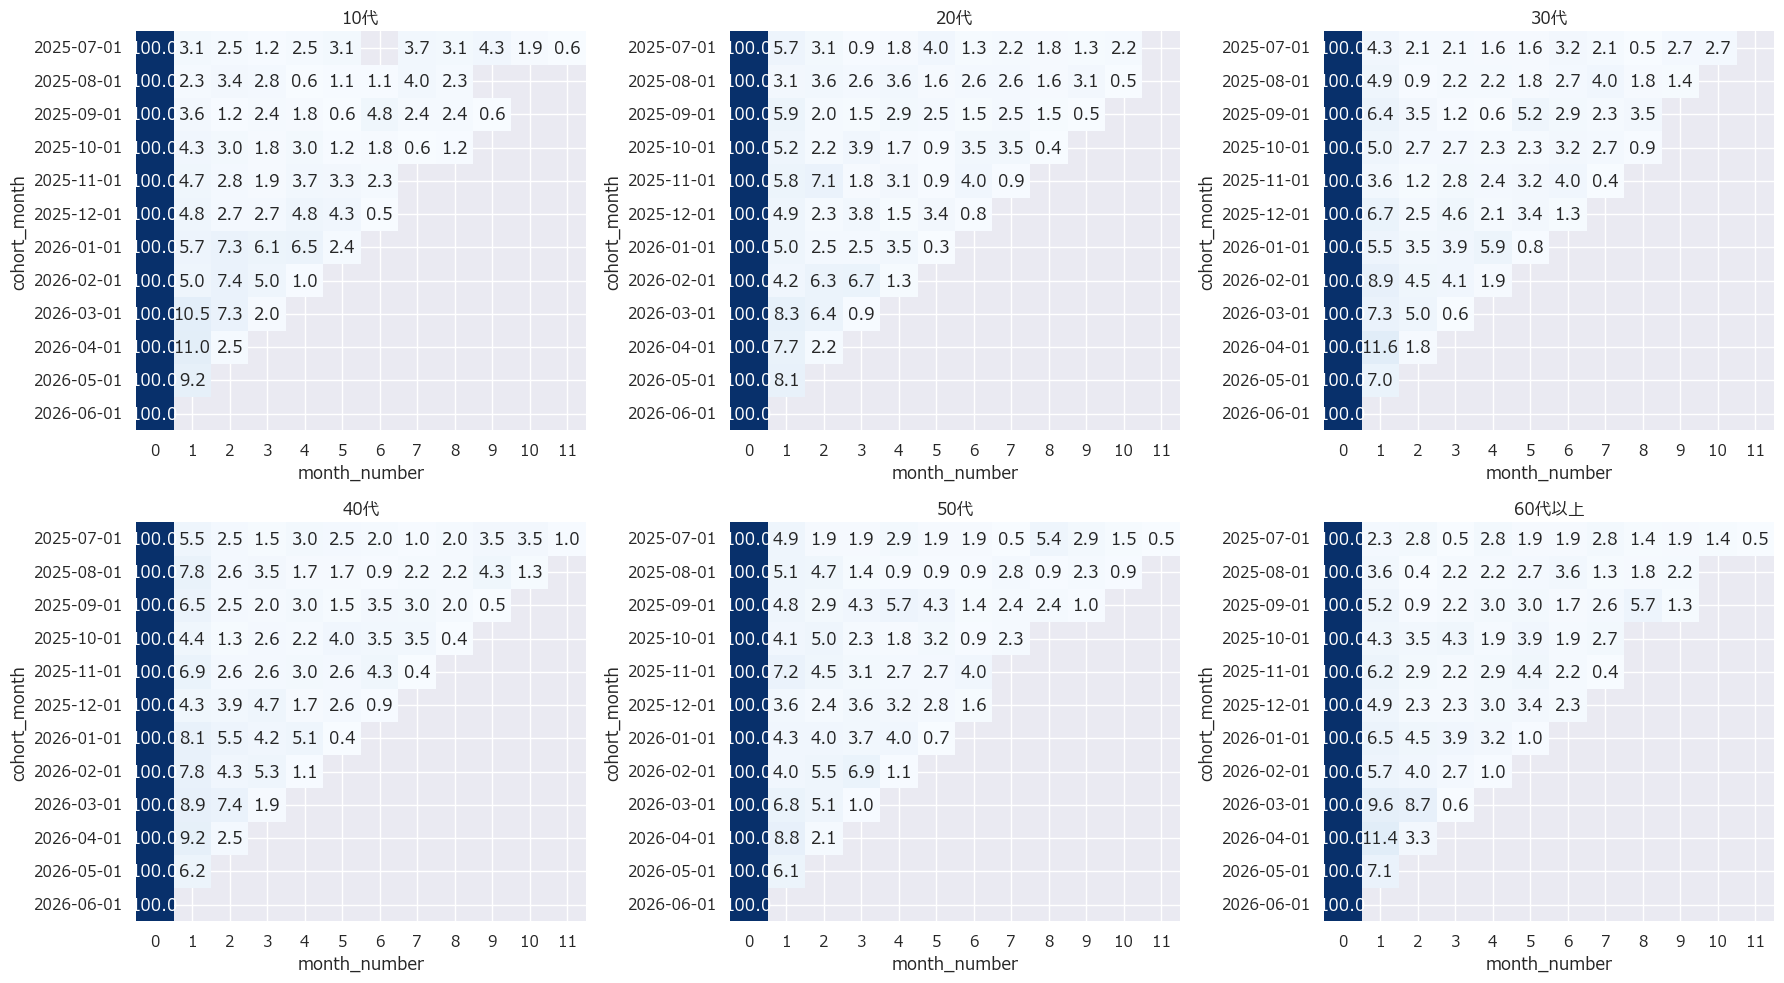

In [51]:
age_groups = ["10代", "20代", "30代", "40代", "50代", "60代以上"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for age, ax in zip(age_groups, axes.flatten()):

    temp = df_cohort_age[df_cohort_age["age_group"] == age]

    cohort_pivot = temp.pivot(
        index="cohort_month",
        columns="month_number",
        values="retention_rate"
    )

    cohort_pivot = cohort_pivot.iloc[-12:, :12]

    sns.heatmap(
        cohort_pivot,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        ax=ax,
        cbar=False
    )

    ax.set_title(age)

plt.tight_layout()
plt.savefig("Retention_Rate.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

全体で見ると、90%は1ヶ月で離脱していることが分かります。その後の数か月の離脱率の減少は少ないため、初回購入後の1ヶ月以内の離脱を防ぐことがリピートにつながっていると考えます。年代別で見ると、10,30,60代のここ最近のリピート率がこの中では高いことが分かります。EDA分析の際に年代別顧客の購入数と総利益を確認したところ、10代は購入数も総利益も少ないにも関わらず、リピート率が高いことが分かります。まず初めにリピート顧客を増やすことを優先することで、そもそもの顧客の母数を増やし、RFMの三要素の底上げを狙うことでランクアップにつなげられる可能性があります。


## 6.施策提案
**施策①：クーポン・チケットの配布**
- ターゲット：全顧客
- 目的：購入回数の増加
- 内容：次回購入10%引きや、セットで買うと安くなるクーポン、5枚チケットを集めることで好きな商品を25%引きなどのクーポン・チケットを配布することで、次回購入の促進を期待します。

**施策②：Jeans,OuterWearの種類増加**
- ターゲット：優良顧客
- 目的：高額商品購入への促進
- 内容：一つのカテゴリの中で、多くの種類の商品を置くことで多くの人に合った商品と出会うことができます。


施策②に関しては、リピーターが増えてからという前提があることで利益拡大の見込みが考えられる施策なので、まずは施策①を中心に行い、状況をみて施策②を取り組みます。